## NOTE 
### This Model was Trained And Tested on Original Dataset of over 6 million entries : but due to size issues, it has been reduced to  2200 for github only, to access the original dataset, redirect to info.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

In [2]:
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

importing the dataset


In [4]:
df = pd.read_csv("dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


analyzing the dataset 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
print(df['isFraud'].value_counts())
df['isFlaggedFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [8]:
print( df.isnull().sum().sum() )

df.shape


0


(6362620, 11)

In [9]:
#percentage of fraud : 

print(round((df["isFraud"].value_counts()[1] /df.shape[0]) *100, 3))

0.129


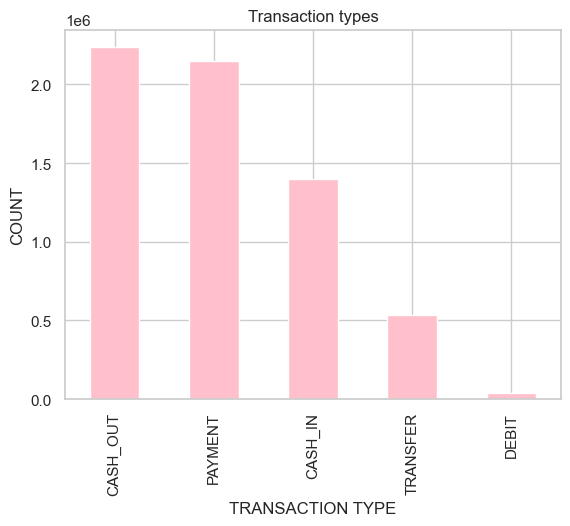

In [10]:
# Analyzing transition types 

df['type'].value_counts().plot(kind='bar', title='Transaction types', color ='pink')
plt.xlabel("TRANSACTION TYPE")
plt.ylabel("COUNT")
plt.show()

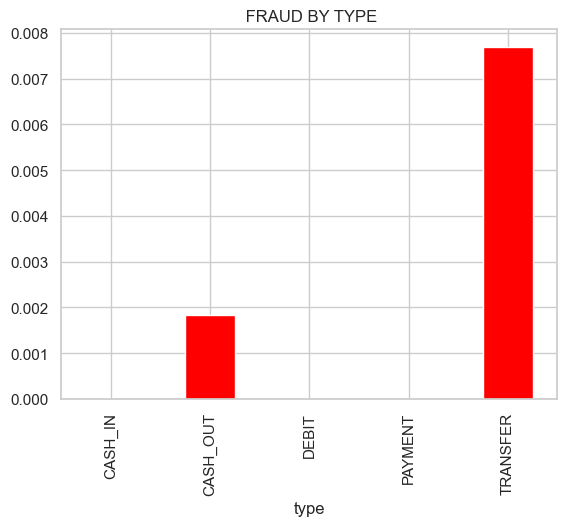

In [11]:
# fraud rates by type


fraudByType = df.groupby("type")['isFraud'].mean()
fraudByType.plot(kind='bar', title=' FRAUD BY TYPE', color = 'red')
plt.show()

In [12]:
fraudByType

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64

In [13]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

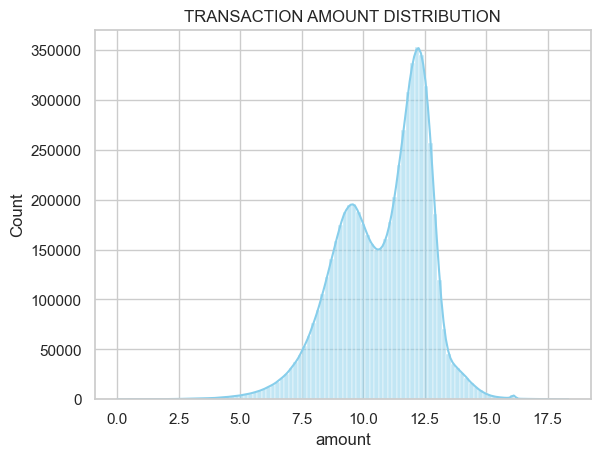

In [14]:
sns.histplot(np.log1p(df['amount']), bins=100, kde = True, color = 'skyblue')
plt.title("TRANSACTION AMOUNT DISTRIBUTION")
plt.show()

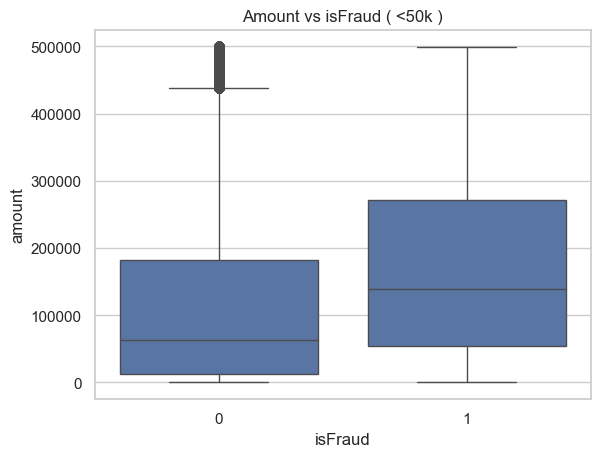

In [15]:
sns.boxplot(data = df[df['amount']<500000], x = "isFraud" , y='amount')
plt.title("Amount vs isFraud ( <50k )")
plt.show()

In [16]:
df["balanceDiffOrig"] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [17]:
print((df['balanceDiffOrig'] < 0).sum())
print((df['balanceDiffDest'] < 0).sum())

1399253
1238864


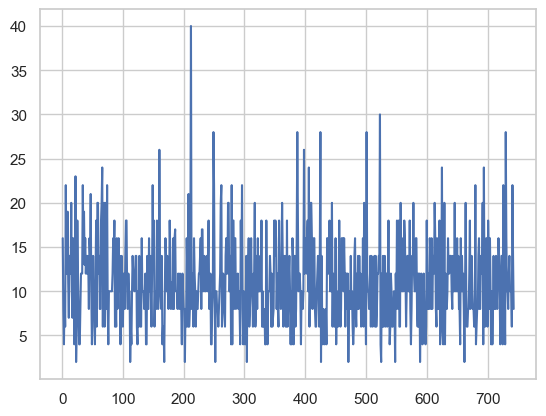

In [18]:
fraudsPerStep = df[df['isFraud'] == 1]["step"].value_counts().sort_index()
plt.plot(fraudsPerStep.index ,  fraudsPerStep.values, label="FRAUDS PER STEP ")
plt.grid = True
plt.show()

In [19]:
df.drop(columns='step', inplace=True)
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [20]:
topSenders = df['nameOrig'].value_counts().head(10)
topSenders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [21]:
topReceivers = df['nameDest'].value_counts().head(10)
topReceivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [22]:
fraudUsers = df[df['isFraud'] == 1 ].value_counts().head(10)
fraudUsers

type      amount     nameOrig     oldbalanceOrg  newbalanceOrig  nameDest     oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  balanceDiffOrig  balanceDiffDest
CASH_OUT  0.00       C10965156    0.00           0.0             C1493336195  230289.66       230289.66       1        0               0.00             0.00               1
TRANSFER  176776.55  C1282030759  176776.55      0.0             C2119586471  0.00            0.00            1        0               176776.55        0.00               1
          202978.65  C1932446672  0.00           0.0             C966173999   2122336.55      2325315.19      1        0               0.00             202978.64          1
          202968.27  C1447646431  202968.27      0.0             C1137974608  0.00            0.00            1        0               202968.27        0.00               1
          202952.03  C738020926   202952.03      0.0             C1822733472  0.00            0.00            1        0               20295

In [23]:
fraudTypes = df[ df['type'].isin( [ 'TRANSFER', 'CASH_OUT'])]
fraudTypes['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

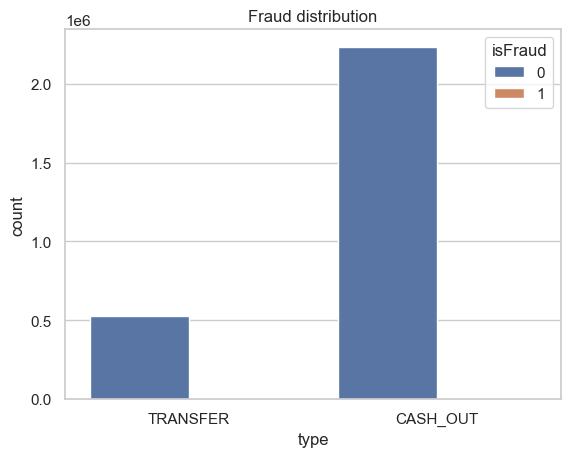

In [24]:
sns.countplot(data=fraudTypes, x ="type" , hue = 'isFraud')
plt.title("Fraud distribution")
plt.show()

<Axes: >

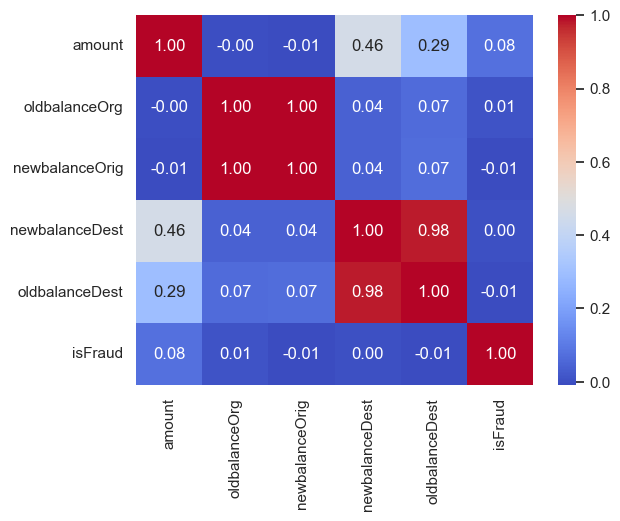

In [25]:
corr = df[['amount', "oldbalanceOrg", "newbalanceOrig", "newbalanceDest", "oldbalanceDest","isFraud"]].corr()
sns.heatmap(corr, annot= True, cmap='coolwarm', fmt=".2f") 

In [26]:
zeroAfter = df[ 
    (df['oldbalanceOrg'] >0) & (df['newbalanceOrig'] == 0 ) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
    ]

In [27]:
len(zeroAfter)
zeroAfter.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


this marks the end of Exploratory Data Analysis 

### FEATURE SELECTION AND ENGINEERING

In [28]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [30]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [31]:
df_model = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis =1 )
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [32]:
categorical = ['type']
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest','newbalanceDest']

In [33]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis = 1)

In [34]:
XTrain, XTest, YTrain, YTest = train_test_split( X,y, test_size=0.3, stratify=y)

In [35]:
# preprocessing data 

preprocessor = ColumnTransformer(
    transformers= [
        ( "num" , StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop='first'), categorical)
     ],
    remainder='drop'
)

In [36]:
# creating model pipeline 

pipeline = Pipeline( [ 
    ( 'prep', preprocessor),
    ('clf', LogisticRegression(class_weight="balanced", max_iter=1000))
    ])

In [37]:
pipeline.fit( XTrain, YTrain)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
yPred = pipeline.predict(XTest)


In [41]:
print(classification_report(YTest, yPred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.94      0.97   1908786



In [42]:
confusion_matrix(YTest, yPred)

array([[1799637,  106685],
       [    129,    2335]])

In [44]:
pipeline.score( XTest, YTest) * 100

94.40408720516601

In [45]:
import joblib 

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']